# customer_purchase_prediction

# Libraries installed 

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

# 2.Load Dataset

In [19]:
df = pd.read_csv("customer_purchase_prediction.csv")

# 3.Dataset Shape

In [20]:
df.shape

(600, 5)

# 4.Dataset Preview

In [21]:
df.head()

,age,income,website_visits,previous_purchases,purchased
0,51,106497,21,0,Yes
1,28,69879,20,0,No
2,27,79871,19,6,Yes
3,32,109388,19,0,Yes
4,34,118646,12,0,No


# 5. Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 600 non-null    int64
 1   income              600 non-null    int64
 2   website_visits      600 non-null    int64
 3   previous_purchases  600 non-null    int64
 4   purchased           600 non-null    str  
dtypes: int64(4), str(1)
memory usage: 23.6 KB


# 6. Descriptive Statistics

In [6]:
df.describe()

,age,income,website_visits,previous_purchases
count,600.000000,600.000000,600.000000,600.000000
mean,41.283333,69747.285000,15.210000,4.416667
std,13.330638,29223.432584,8.375728,2.923006
min,18.000000,20138.000000,1.000000,0.000000
25%,30.000000,43092.750000,8.000000,2.000000
50%,41.000000,69863.000000,15.000000,4.000000
75%,52.000000,95770.250000,22.000000,7.000000
max,64.000000,119932.000000,29.000000,9.000000


# 7.Preprocessing


# Convert target Yes/No → 1/0

In [43]:
le = LabelEncoder()
df['purchased'] = le.fit_transform(df['purchased'])

# Features & Target
X = df[['age', 'income', 'website_visits']]  
y = df['purchased']

# 8. Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 9. Feature Scaling

In [45]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 10. Model Training


In [46]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# 11. Prediction

In [47]:
y_pred = model.predict(X_test)

# 12. Evaluation

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7583333333333333
Precision: 0.6825396825396826
Recall: 0.8269230769230769
F1 Score: 0.7478260869565218


In [49]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.84166667 0.78333333 0.775      0.775      0.775     ]
Mean accuracy: 0.7899999999999999


# 13.Visualization

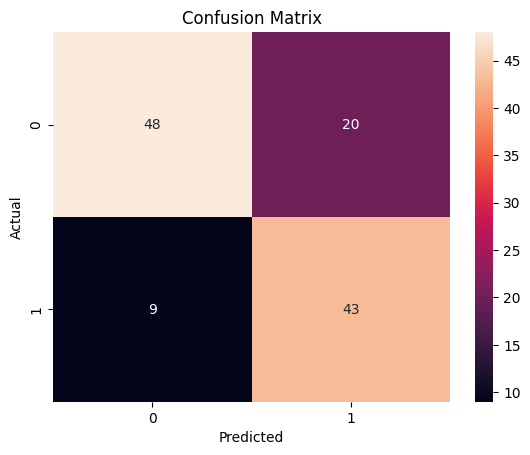

In [50]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

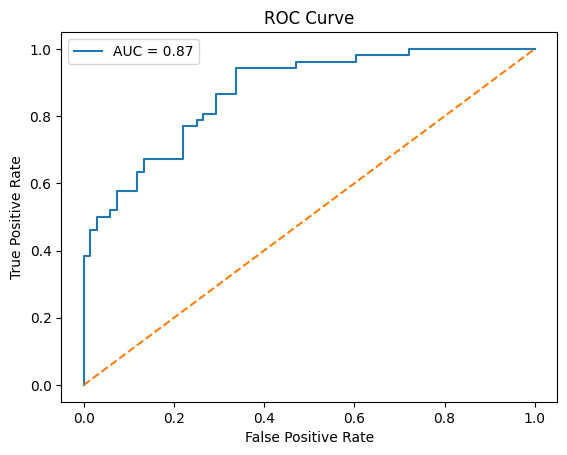

In [51]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [52]:
import pandas as pd

coefficients = model.coef_.flatten()
features = X.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df)

          Feature  Coefficient
2  website_visits     1.855404
1          income     1.669134
0             age    -0.222871


# create a new data to predict the output 

In [54]:
new_customer = pd.DataFrame(
    [[25, 100000, 12, ]],
    columns=['age', 'income', 'website_visits', ]
)

new_customer = scaler.transform(new_customer)

result = model.predict(new_customer)

# Always calculate probability (outside if-else)
prob = model.predict_proba(new_customer)

if result[0] == 1:
    print("Customer WILL purchase")
else:
    print("Customer will NOT purchase")

print(f"Purchase Probability: {prob[0][1]:.2f}")

Customer WILL purchase
Purchase Probability: 0.73
